##### Copyright 2025 Google LLC.

In [3]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the Liimport datetime as dtcense.

In [4]:
!pip uninstall -qqy jupyterlab  # Remove unused packages from Kaggle's base image that conflict
!pip install -U -q "google-genai==1.7.0"

In [5]:
from google import genai
from google.genai import types

from IPython.display import HTML, Markdown, display

Set up a retry helper. This allows you to "Run all" without worrying about per-minute quota.

In [6]:
from google.api_core import retry


is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

genai.models.Models.generate_content = retry.Retry(
    predicate=is_retriable)(genai.models.Models.generate_content)

### Set up your API key

To run the following cell, your API key must be stored it in a [Kaggle secret](https://www.kaggle.com/discussions/product-feedback/114053) named `GOOGLE_API_KEY`.

If you don't already have an API key, you can grab one from [AI Studio](https://aistudio.google.com/app/apikey). You can find [detailed instructions in the docs](https://ai.google.dev/gemini-api/docs/api-key).

To make the key available through Kaggle secrets, choose `Secrets` from the `Add-ons` menu and follow the instructions to add your key or enable it for this notebook.

In [7]:
from kaggle_secrets import UserSecretsClient

GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")

# **QUERYING A DATABASE WITH GENAI**



**Here I have generated a database with 60 days' worth of fitness data similar to data collected from a fitbit. The database stores the information in different tables, and the model can be queried to look up and display data present in diffeent tables. If the user wants to know what day they covered the maximum number of steps, then the model performs the necessary operations.**

In [8]:
import pandas as pd
import sqlite3
from datetime import datetime, timedelta
import random

db_name = "health.db"

# --- Table: CaloriesConsumedDaily ---
start_date = datetime(2024, 3, 17)
dates = [start_date + timedelta(days=i) for i in range(60)]
calories_consumed = [random.randint(1800, 2500) for _ in range(60)]

df_calories_consumed = pd.DataFrame({
    'Date': [d.strftime('%Y-%m-%d') for d in dates],
    'CaloriesConsumed': calories_consumed
})

# --- Table: StepAnalysisDaily ---
brisk_steps = [random.randint(1000, 5000) for _ in range(60)]
slow_steps = [random.randint(2000, 8000) for _ in range(60)]
run_steps = [random.randint(0, 2000) for _ in range(60)]
minutes = [random.choice([30, 45, 60, 90]) for i in range(60)]
lightly_active_minutes = [random.choice([4,5,6])*60 for i in range(60)]
moderately_active_minutes = [random.choice([1,2,3])*60 for i in range(60)]

weight_in_kg = [round(random.uniform(80, 70), 2) for _ in range(60)]
weight_in_kg.sort(reverse=True)

df_workout_analysis = pd.DataFrame({
    'Date': [d.strftime('%Y-%m-%d') for d in dates],
    'Minutes' : minutes
})

df_activity_analysis = pd.DataFrame({
    'Date': [d.strftime('%Y-%m-%d') for d in dates],
    'LightlyActiveMinutes': lightly_active_minutes,
    'ModeratelyActiveMinutes': moderately_active_minutes
})

df_step_analysis = pd.DataFrame({
    'Date': [d.strftime('%Y-%m-%d') for d in dates],
    'BriskSteps': brisk_steps,
    'SlowSteps': slow_steps,
    'RunSteps': run_steps,
    'WeightKg': weight_in_kg  # Added daily weight
})

# --- Fixed Calorie Burn Rates ---
calorie_burn_rates = {
    'brisksteps': 0.04,  # Calories burned per step
    'slowsteps': 0.02,   # Calories burned per step
    'runsteps': 0.06,     # Calories burned per step
    'lightlyactive': 2,    # Calories burned per minute
    'moderatelyactive': 4,    # Calories burned per minute
    'workout': 10             # Calories burned per minute
}

df_burn_rates_steps = pd.DataFrame({
    'StepType': ['brisksteps', 'slowsteps', 'runsteps'],
    'CaloriesPerStep': [calorie_burn_rates['brisksteps'], calorie_burn_rates['slowsteps'], calorie_burn_rates['runsteps']]
})

df_burn_rates_minutes = pd.DataFrame({
    'ActivityType': ['lightlyactive', 'moderatelyactive', 'workout'],
    'CaloriesPerMinute': [calorie_burn_rates['lightlyactive'], calorie_burn_rates['moderatelyactive'], calorie_burn_rates['workout']]
})


# Create the database and write the DataFrames to tables
conn = sqlite3.connect(db_name)

df_calories_consumed.to_sql('calories_consumed_daily', conn, if_exists='replace', index=False)
df_step_analysis.to_sql('step_analysis_daily', conn, if_exists='replace', index=False)
df_burn_rates_steps.to_sql('calorie_burn_rates_per_step', conn, if_exists='replace', index=False)
df_burn_rates_minutes.to_sql('calorie_burn_rates_per_minute', conn, if_exists='replace', index=False)
df_workout_analysis.to_sql('workout_daily', conn, if_exists='replace', index=False)
df_activity_analysis.to_sql('activity_daily', conn, if_exists='replace', index=False)


# conn.close()

print(f"Database '{db_name}' created with tables 'calories_consumed_daily', 'step_analysis_daily' (with WeightKg), 'activity_daily', 'workout_daily', 'calorie_burn_rates_per_step', and 'calorie_burn_rates_per_minute'.")

Database 'health.db' created with tables 'calories_consumed_daily', 'step_analysis_daily' (with WeightKg), 'activity_daily', 'workout_daily', 'calorie_burn_rates_per_step', and 'calorie_burn_rates_per_minute'.


In [9]:
def list_tables() -> list[str]:
    print(' - DB CALL: list_tables()')
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [t[0] for t in tables]


list_tables()

 - DB CALL: list_tables()


['calories_consumed_daily',
 'step_analysis_daily',
 'calorie_burn_rates_per_step',
 'calorie_burn_rates_per_minute',
 'workout_daily',
 'activity_daily']

In [10]:
def describe_table(table_name: str) -> list[tuple[str, str]]:
    print(f' - DB CALL: describe_table({table_name})')
    cursor = conn.cursor()
    cursor.execute(f"PRAGMA table_info({table_name});")
    schema = cursor.fetchall()
    return [(col[1], col[2]) for col in schema]

describe_table("calories_consumed_daily")

 - DB CALL: describe_table(calories_consumed_daily)


[('Date', 'TEXT'), ('CaloriesConsumed', 'INTEGER')]

In [11]:
describe_table("step_analysis_daily")

 - DB CALL: describe_table(step_analysis_daily)


[('Date', 'TEXT'),
 ('BriskSteps', 'INTEGER'),
 ('SlowSteps', 'INTEGER'),
 ('RunSteps', 'INTEGER'),
 ('WeightKg', 'REAL')]

In [12]:
describe_table("calorie_burn_rates_per_step")

 - DB CALL: describe_table(calorie_burn_rates_per_step)


[('StepType', 'TEXT'), ('CaloriesPerStep', 'REAL')]

In [13]:
describe_table("calorie_burn_rates_per_minute")

 - DB CALL: describe_table(calorie_burn_rates_per_minute)


[('ActivityType', 'TEXT'), ('CaloriesPerMinute', 'INTEGER')]

In [14]:
describe_table("workout_daily")

 - DB CALL: describe_table(workout_daily)


[('Date', 'TEXT'), ('Minutes', 'INTEGER')]

In [15]:
describe_table("activity_daily")

 - DB CALL: describe_table(activity_daily)


[('Date', 'TEXT'),
 ('LightlyActiveMinutes', 'INTEGER'),
 ('ModeratelyActiveMinutes', 'INTEGER')]

In [16]:
def execute_query(sql: str) -> list[list[str]]:
    print(f' - DB CALL: execute_query({sql})')
    cursor = conn.cursor()
    cursor.execute(sql)
    return cursor.fetchall()
execute_query("select * from calories_consumed_daily")

 - DB CALL: execute_query(select * from calories_consumed_daily)


[('2024-03-17', 2289),
 ('2024-03-18', 1901),
 ('2024-03-19', 1986),
 ('2024-03-20', 2245),
 ('2024-03-21', 2473),
 ('2024-03-22', 2184),
 ('2024-03-23', 2419),
 ('2024-03-24', 2213),
 ('2024-03-25', 1962),
 ('2024-03-26', 2196),
 ('2024-03-27', 2490),
 ('2024-03-28', 2052),
 ('2024-03-29', 2272),
 ('2024-03-30', 2251),
 ('2024-03-31', 1821),
 ('2024-04-01', 2425),
 ('2024-04-02', 2198),
 ('2024-04-03', 2018),
 ('2024-04-04', 2379),
 ('2024-04-05', 1862),
 ('2024-04-06', 2395),
 ('2024-04-07', 1885),
 ('2024-04-08', 2058),
 ('2024-04-09', 1861),
 ('2024-04-10', 2361),
 ('2024-04-11', 1838),
 ('2024-04-12', 1821),
 ('2024-04-13', 2364),
 ('2024-04-14', 2048),
 ('2024-04-15', 1866),
 ('2024-04-16', 2031),
 ('2024-04-17', 2444),
 ('2024-04-18', 1827),
 ('2024-04-19', 1920),
 ('2024-04-20', 2106),
 ('2024-04-21', 1874),
 ('2024-04-22', 2091),
 ('2024-04-23', 1901),
 ('2024-04-24', 2478),
 ('2024-04-25', 2384),
 ('2024-04-26', 2444),
 ('2024-04-27', 1801),
 ('2024-04-28', 2363),
 ('2024-04-

In [17]:
execute_query('SELECT * FROM step_analysis_daily')



 - DB CALL: execute_query(SELECT * FROM step_analysis_daily)


[('2024-03-17', 3880, 3225, 1054, 79.83),
 ('2024-03-18', 1475, 5607, 67, 79.79),
 ('2024-03-19', 3746, 4451, 1117, 79.69),
 ('2024-03-20', 2884, 5777, 1181, 79.67),
 ('2024-03-21', 3403, 6082, 551, 79.64),
 ('2024-03-22', 2019, 6126, 185, 79.63),
 ('2024-03-23', 2264, 6522, 1503, 79.52),
 ('2024-03-24', 3248, 2945, 544, 79.39),
 ('2024-03-25', 4962, 6305, 443, 79.28),
 ('2024-03-26', 4985, 5352, 1688, 79.17),
 ('2024-03-27', 2165, 5112, 486, 79.1),
 ('2024-03-28', 3784, 7701, 1020, 79.04),
 ('2024-03-29', 4304, 2748, 1018, 78.95),
 ('2024-03-30', 1871, 7450, 1606, 78.94),
 ('2024-03-31', 2105, 5438, 1149, 78.39),
 ('2024-04-01', 2682, 3570, 82, 78.33),
 ('2024-04-02', 3060, 7606, 1916, 78.16),
 ('2024-04-03', 2179, 4390, 1426, 78.03),
 ('2024-04-04', 4619, 5687, 1457, 77.75),
 ('2024-04-05', 3474, 2056, 175, 77.51),
 ('2024-04-06', 2297, 7134, 1908, 77.51),
 ('2024-04-07', 4994, 5786, 51, 77.49),
 ('2024-04-08', 1965, 7448, 447, 77.17),
 ('2024-04-09', 3344, 5914, 256, 77.02),
 ('2024

In [18]:
execute_query('SELECT * FROM calorie_burn_rates_per_step')


 - DB CALL: execute_query(SELECT * FROM calorie_burn_rates_per_step)


[('brisksteps', 0.04), ('slowsteps', 0.02), ('runsteps', 0.06)]

In [19]:
execute_query('SELECT * FROM calorie_burn_rates_per_minute')


 - DB CALL: execute_query(SELECT * FROM calorie_burn_rates_per_minute)


[('lightlyactive', 2), ('moderatelyactive', 4), ('workout', 10)]

In [20]:
execute_query('SELECT * FROM workout_daily')


 - DB CALL: execute_query(SELECT * FROM workout_daily)


[('2024-03-17', 45),
 ('2024-03-18', 60),
 ('2024-03-19', 30),
 ('2024-03-20', 30),
 ('2024-03-21', 30),
 ('2024-03-22', 30),
 ('2024-03-23', 60),
 ('2024-03-24', 90),
 ('2024-03-25', 90),
 ('2024-03-26', 60),
 ('2024-03-27', 90),
 ('2024-03-28', 45),
 ('2024-03-29', 60),
 ('2024-03-30', 30),
 ('2024-03-31', 60),
 ('2024-04-01', 60),
 ('2024-04-02', 90),
 ('2024-04-03', 90),
 ('2024-04-04', 90),
 ('2024-04-05', 60),
 ('2024-04-06', 30),
 ('2024-04-07', 30),
 ('2024-04-08', 90),
 ('2024-04-09', 90),
 ('2024-04-10', 60),
 ('2024-04-11', 60),
 ('2024-04-12', 90),
 ('2024-04-13', 30),
 ('2024-04-14', 60),
 ('2024-04-15', 30),
 ('2024-04-16', 30),
 ('2024-04-17', 90),
 ('2024-04-18', 60),
 ('2024-04-19', 90),
 ('2024-04-20', 90),
 ('2024-04-21', 45),
 ('2024-04-22', 60),
 ('2024-04-23', 30),
 ('2024-04-24', 30),
 ('2024-04-25', 45),
 ('2024-04-26', 90),
 ('2024-04-27', 30),
 ('2024-04-28', 45),
 ('2024-04-29', 60),
 ('2024-04-30', 90),
 ('2024-05-01', 60),
 ('2024-05-02', 60),
 ('2024-05-03

In [21]:
execute_query('SELECT * FROM activity_daily')


 - DB CALL: execute_query(SELECT * FROM activity_daily)


[('2024-03-17', 240, 60),
 ('2024-03-18', 240, 180),
 ('2024-03-19', 360, 120),
 ('2024-03-20', 300, 60),
 ('2024-03-21', 300, 120),
 ('2024-03-22', 240, 180),
 ('2024-03-23', 360, 120),
 ('2024-03-24', 300, 120),
 ('2024-03-25', 360, 60),
 ('2024-03-26', 300, 120),
 ('2024-03-27', 300, 60),
 ('2024-03-28', 300, 60),
 ('2024-03-29', 240, 180),
 ('2024-03-30', 360, 180),
 ('2024-03-31', 300, 60),
 ('2024-04-01', 360, 120),
 ('2024-04-02', 300, 60),
 ('2024-04-03', 240, 60),
 ('2024-04-04', 360, 180),
 ('2024-04-05', 360, 120),
 ('2024-04-06', 360, 120),
 ('2024-04-07', 240, 180),
 ('2024-04-08', 240, 120),
 ('2024-04-09', 300, 120),
 ('2024-04-10', 360, 120),
 ('2024-04-11', 240, 120),
 ('2024-04-12', 300, 120),
 ('2024-04-13', 240, 120),
 ('2024-04-14', 240, 120),
 ('2024-04-15', 360, 180),
 ('2024-04-16', 240, 120),
 ('2024-04-17', 300, 60),
 ('2024-04-18', 240, 60),
 ('2024-04-19', 360, 60),
 ('2024-04-20', 360, 180),
 ('2024-04-21', 240, 60),
 ('2024-04-22', 360, 60),
 ('2024-04-23'

In [22]:
db_tools = [list_tables, describe_table, execute_query]

instruction = """You are a helpful chatbot that can interact with an SQL database
containing tables with fitness data. You will take the users questions and turn them into SQL
queries using the tools available. Once you have the information you need, you will
answer the user's question using the data returned.

Use list_tables to see what tables are present, describe_table to understand the
schema, and execute_query to issue an SQL SELECT query.

If required use queries to join tables using join command to get answers.

Some pre-requisite knowledge - the final total number of calories burned on a day is calculated from the calorie_burn_rates table 
where for example 100 brisk steps and 200 slow steps equals 100 * 0.04 + 200 * 0.02 = 8 calories burned.
Additionally on the same day, the workout minutes * calories burned per minute for workout(10) + light activity minutes * calories burned per minute for light activity(2)
+ moderate activity minutes * calories burned per minute for moderate activity(2) need to be considered.

The total gain or loss of calories for a day is the final total calories burned - calories consumed. If the burned > consumed then overall calorie deficit. Else gained.
"""

client = genai.Client(api_key=GOOGLE_API_KEY)

# Start a chat with automatic function calling enabled.
chat = client.chats.create(
    model="gemini-2.0-flash",
    config=types.GenerateContentConfig(
        system_instruction=instruction,
        tools=db_tools,
    ),
)

In [23]:
resp = chat.send_message("What day did the person burn the most calories? Could you explain step by step to reach the answer? Also mention the calorie amounts ")
Markdown(f"\n{resp.text}")

 - DB CALL: list_tables()
 - DB CALL: describe_table(step_analysis_daily)
 - DB CALL: describe_table(calorie_burn_rates_per_step)
 - DB CALL: describe_table(workout_daily)
 - DB CALL: describe_table(activity_daily)
 - DB CALL: describe_table(calorie_burn_rates_per_minute)
 - DB CALL: execute_query(SELECT
  s.Date,
  SUM(
    (
      s.BriskSteps * (
        SELECT
          CaloriesPerStep
        FROM calorie_burn_rates_per_step
        WHERE
          StepType = 'BriskSteps'
      )
    ) + (
      s.SlowSteps * (
        SELECT
          CaloriesPerStep
        FROM calorie_burn_rates_per_step
        WHERE
          StepType = 'SlowSteps'
      )
    ) + (
      s.RunSteps * (
        SELECT
          CaloriesPerStep
        FROM calorie_burn_rates_per_step
        WHERE
          StepType = 'RunSteps'
      )
    ) + (
      w.Minutes * (
        SELECT
          CaloriesPerMinute
        FROM calorie_burn_rates_per_minute
        WHERE
          ActivityType = 'workout'
      )
 


Great! The day with the most calories burned is **2024-05-11**, with a total of **900 calories** burned.


In [24]:
resp = chat.send_message("What was the total number of steps on all the days individually?")
print(f"\n{resp.text}")

 - DB CALL: execute_query(SELECT Date, BriskSteps + SlowSteps + RunSteps AS TotalSteps FROM step_analysis_daily)

Here is the total number of steps for each day:

*   2024-03-17: 8159 steps
*   2024-03-18: 7149 steps
*   2024-03-19: 9314 steps
*   2024-03-20: 9842 steps
*   2024-03-21: 10036 steps
*   2024-03-22: 8330 steps
*   2024-03-23: 10289 steps
*   2024-03-24: 6737 steps
*   2024-03-25: 11710 steps
*   2024-03-26: 12025 steps
*   2024-03-27: 7763 steps
*   2024-03-28: 12505 steps
*   2024-03-29: 8070 steps
*   2024-03-30: 10927 steps
*   2024-03-31: 8692 steps
*   2024-04-01: 6334 steps
*   2024-04-02: 12582 steps
*   2024-04-03: 7995 steps
*   2024-04-04: 11763 steps
*   2024-04-05: 5705 steps
*   2024-04-06: 11339 steps
*   2024-04-07: 10831 steps
*   2024-04-08: 9860 steps
*   2024-04-09: 9514 steps
*   2024-04-10: 8504 steps
*   2024-04-11: 10694 steps
*   2024-04-12: 9648 steps
*   2024-04-13: 11737 steps
*   2024-04-14: 7086 steps
*   2024-04-15: 9952 steps
*   2024-04-16:

# **GYM-BOT**

**Here I have a GYM-BOT, basically a chat assistant that would help users log their daily data into the above database, into the respective tables, and also query the models regarding any other fitness or dietary advice. There is also a function to check if the date's information has been logged, and a delete all information for a day, if needed.**

In [ ]:
# GYM-BOT

In [26]:
# Remove conflicting packages from the Kaggle base environment.
!pip uninstall -qqy kfp jupyterlab libpysal thinc spacy fastai ydata-profiling google-cloud-bigquery google-generativeai
# Install langgraph and the packages used in this lab.
!pip install -qU 'langgraph==0.3.21' 'langchain-google-genai==2.1.2' 'langgraph-prebuilt==0.1.7'

In [27]:
import os
from kaggle_secrets import UserSecretsClient

GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [64]:
from typing import Annotated, Optional, Literal, List
from typing_extensions import TypedDict
from langgraph.graph import END

from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, SystemMessage
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode

import sqlite3
from IPython.display import Markdown, display

DATABASE_PATH = "health.db"

def get_db_connection():
    return sqlite3.connect(DATABASE_PATH)

@tool
def execute_query(sql: str) -> list[tuple]:
    """ Executes sql queries """
    print(f' - DB CALL: execute_query({sql})')
    conn = get_db_connection()
    cursor = conn.cursor()
    cursor.execute(sql)
    results = cursor.fetchall()
    conn.close()
    return results


@tool
def describe_table(table_name: str) -> list[tuple[str, str]]:
    """ Describes tables """
    print(f' - DB CALL: describe_table({table_name})')
    conn = get_db_connection()
    cursor = conn.cursor()
    cursor.execute(f"PRAGMA table_info({table_name});")
    schema = cursor.fetchall()
    conn.close()
    return [(col[1], col[2]) for col in schema]


@tool
def list_tables() -> list[str]:
    """Lists tables in db
        """
    print(' - DB CALL: list_tables()')
    conn = get_db_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    conn.close()
    return [t[0] for t in tables]


@tool
def insert_daily_info(daily_data: dict) -> str:
    """Inserts the daily fitness information into the database."""
    date = daily_data["date"]
    brisk_steps = daily_data["brisk_steps"]
    slow_steps = daily_data["slow_steps"]
    run_steps = daily_data["run_steps"]
    weight_kg = daily_data["weight_kg"]
    lightly_active_minutes = daily_data["lightly_active_minutes"]
    moderately_active_minutes = daily_data["moderately_active_minutes"]
    workout_minutes = daily_data["workout_minutes"]
    calories_consumed = daily_data["calories_consumed"]

    conn = get_db_connection()
    cursor = conn.cursor()
    try:
        cursor.execute("""
            INSERT INTO step_analysis_daily (Date, BriskSteps, SlowSteps, RunSteps, WeightKg)
            VALUES (?, ?, ?, ?, ?)
        """, (date, brisk_steps, slow_steps, run_steps, weight_kg))
        cursor.execute("""
            INSERT INTO activity_daily (Date, LightlyActiveMinutes, ModeratelyActiveMinutes)
            VALUES (?, ?, ?)
        """, (date, lightly_active_minutes, moderately_active_minutes))
        cursor.execute("""
            INSERT INTO workout_daily (Date, Minutes)
            VALUES (?, ?)
        """, (date, workout_minutes))
        cursor.execute("""
            INSERT INTO calories_consumed_daily (Date, CaloriesConsumed)
            VALUES (?, ?)
        """, (date, calories_consumed))
        conn.commit()
        conn.close()
        return f"Daily information for {date} inserted successfully."
    except sqlite3.Error as e:
        conn.close()
        return f"Error inserting information: {e}"

@tool
def log_daily_info() -> str:
    """Asks the user for their daily fitness information."""
    return "OK. I will log your daily fitness information. What is the date (YYYY-MM-DD), brisk steps, slow steps, run steps, weight (kg), lightly active minutes, moderately active minutes, workout minutes, and calories consumed, separated by commas?"

@tool
def parse_daily_info(info_string: str) -> Optional[dict]:
    """Parses the daily fitness information string."""
    try:
        parts = info_string.split(',')
        if len(parts) == 9:
            return {
                "date": parts[0].strip(),
                "brisk_steps": int(parts[1].strip()),
                "slow_steps": int(parts[2].strip()),
                "run_steps": int(parts[3].strip()),
                "weight_kg": float(parts[4].strip()),
                "lightly_active_minutes": int(parts[5].strip()),
                "moderately_active_minutes": int(parts[6].strip()),
                "workout_minutes": int(parts[7].strip()),
                "calories_consumed": int(parts[8].strip()),
            }
        else:
            return None
    except ValueError:
        return None

class GymBotState(TypedDict):
    """State representing the user's gym interaction conversation."""
    messages: Annotated[List[BaseMessage], "Chat history"]
    daily_info_raw: Optional[str]
    daily_entry: Optional[dict]
    finished: bool

GYMBOT_SYSINT = (
    "system",
    "You are GymBot, your interactive fitness and diet assistant. "
    "You can help users log their daily fitness information and provide advice on diet and exercise."
    "\n\n"
    "To log daily information, use the log_daily_info tool. "
    "You will need to ask the user for the date (YYYY-MM-DD), brisk steps, slow steps, run steps, weight (kg), "
    "lightly active minutes, moderately active minutes, workout minutes, and calories consumed, separated by commas. "
    "Once you have this information, use the parse_daily_info tool to process it, and then use the insert_daily_info tool to save it to the database."
    "\n\n"
    "For dietary or exercise advice, you can directly respond to the user's queries."
    "\n\n"
    "The conversation should end after the user indicates they are done or after data insertion."
)

GYMBOT_WELCOME_MSG = "**Hello!** How can I help you today? I can log your daily fitness information or provide advice on diet and exercise."

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
tools = [execute_query, list_tables, describe_table, log_daily_info, insert_daily_info, parse_daily_info]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

def maybe_route_to_tools(state: GymBotState) -> Literal["tools", "human"]:
    """Route to tools if the last AI message has tool calls or if the state has raw daily info."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    last_msg = msgs[-1]

    if isinstance(last_msg, AIMessage) and hasattr(last_msg, "tool_calls") and len(last_msg.tool_calls) > 0:
        return "tools"
    elif "daily_info_raw" in state and state["daily_info_raw"]:
        return "tools"
    elif isinstance(last_msg, AIMessage) and "provide the date" in last_msg.content.lower():
        return "human"
    return "human"

def handle_tool_output(state: GymBotState) -> GymBotState:
    """Handles the output of the tools."""
    if not state["messages"]:
        print("Warning: handle_tool_output called with empty messages list.")
        return state

    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        tool_output = llm.invoke([AIMessage(content="", tool_calls=last_msg.tool_calls)])
        return {"messages": state["messages"] + [tool_output]}
    elif isinstance(last_msg, AIMessage) and hasattr(last_msg, "tool_result"):
        return state
    elif isinstance(last_msg, BaseMessage) and hasattr(last_msg, "content") and hasattr(last_msg, "type") and last_msg.type == "tool":
        tool_output = last_msg.content
        return {"messages": state["messages"] + [AIMessage(content=str(tool_output), tool_result=tool_output)]}
    return state


def chatbot_with_tools(state: GymBotState) -> GymBotState:
    """The chatbot with tools. A simple wrapper around the model's own chat interface."""
    defaults = {"order": [], "finished": False}
    updated_state = defaults | state

    messages_to_llm = []
    if not updated_state["messages"]:
        new_output = AIMessage(content=GYMBOT_WELCOME_MSG)
    else:
        if len(updated_state["messages"]) == 1 and isinstance(updated_state["messages"][0], HumanMessage):
            messages_to_llm.append(SystemMessage(content=GYMBOT_SYSINT[1]))
        messages_to_llm.extend(updated_state["messages"])

        if messages_to_llm and isinstance(messages_to_llm[-1], AIMessage) and hasattr(messages_to_llm[-1], "tool_result"):
            return updated_state
        else:
            new_output = llm_with_tools.invoke(messages_to_llm)

    return updated_state | {"messages": [new_output]}

def human_node(state: GymBotState) -> GymBotState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    display(Markdown(f"**Model:** {last_msg.content}"))
    user_input = input("User: ")

    if user_input in {"q", "quit", "exit", "goodbye"}:
        return state | {"messages": [HumanMessage(content=user_input)], "finished": True}
    elif "provide the date" in last_msg.content.lower():
        return state | {"messages": [HumanMessage(content=user_input)], "daily_info_raw": user_input}
    else:
        return state | {"messages": [HumanMessage(content=user_input)]}

def parse_info(state: GymBotState) -> GymBotState:
    """Parses the raw daily info string."""
    if "daily_info_raw" in state and state["daily_info_raw"]:
        parsed_info = parse_daily_info(state["daily_info_raw"])
        return state | {
            "messages": state["messages"] + [AIMessage(content=str(parsed_info), tool_result=parsed_info)],
            "daily_entry": parsed_info,
            "daily_info_raw": None,
        }
    return state

def insert_data(state: GymBotState) -> GymBotState:
    """Inserts the daily information into the database and adds the result to messages."""
    if "daily_entry" in state and state["daily_entry"]:
        data = state["daily_entry"]
        try:
            result = insert_daily_info({"daily_data": data})
            updated_messages = state["messages"] + [AIMessage(content=result)]
            return state | {"messages": updated_messages, "daily_entry": None}
        except Exception as e:
            error_message = f"**Error during data insertion:** :warning: {e}"
            updated_messages = state["messages"] + [AIMessage(content=error_message)]
            return state | {"messages": updated_messages, "daily_entry": None}
    return state

def maybe_exit_human_node(state: GymBotState) -> Literal["chatbot", "__end__", "parse_info"]:
    """Route to the chatbot or parsing, unless the user explicitly wants to exit."""
    if state.get("finished", False):
        return "__end__"
    elif "daily_info_raw" in state:
        return "parse_info"
    else:
        return "chatbot"

def should_insert(state: GymBotState) -> bool:
    """Checks if the daily entry has been successfully parsed."""
    should = state.get("daily_entry") is not None
    print(f"--- should_insert evaluated to: {should}, daily_entry: {state.get('daily_entry')}")
    return should

graph_builder = StateGraph(GymBotState)

graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("handle_tool_output", handle_tool_output)
graph_builder.add_node("parse_info", parse_info)
graph_builder.add_node("insert_data", insert_data) # Use the modified function

graph_builder.set_entry_point("chatbot")

graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)
graph_builder.add_conditional_edges("parse_info", lambda state: state.get("daily_entry") is not None, {False: "chatbot", True: "insert_data"})
graph_builder.add_edge("tools", "handle_tool_output")
graph_builder.add_edge("handle_tool_output", "parse_info")
graph_builder.add_edge("insert_data", "chatbot") # Go back to chatbot after insertion attempt

graph_builder.add_edge(START, "chatbot")
graph_with_logging = graph_builder.compile()

# Image(graph_with_logging.get_graph().draw_mermaid_png()) # Commented out

config = {"recursion_limit": 100}
state = {"messages": []} # Start with an empty messages list

while not state.get("finished", False):
    try:
        result = graph_with_logging.invoke(state, config)
        state = result
    except StopIteration:
        print("Graph finished.")
        break

print("Conversation ended.")

**Model:** **Hello!** How can I help you today? I can log your daily fitness information or provide advice on diet and exercise.

User:  Log


**Model:** OK. I am ready to log your daily information.
Please provide the date (YYYY-MM-DD), brisk steps, slow steps, run steps, weight (kg), lightly active minutes, moderately active minutes, workout minutes, and calories consumed, separated by commas.

User:  2024-05-27, 1700, 2100, 1208, 68, 277, 198, 60, 1450


**Model:** 

...

**Model:** For consistent weight loss without completely cutting out sugar, focus on these strategies:

*   **Prioritize Whole Foods:** Build your diet around whole, unprocessed foods like fruits, vegetables, lean proteins, and whole grains. These foods are nutrient-dense and help you feel full.

*   **Mindful Sugar Consumption:** Be mindful of added sugars in processed foods, sugary drinks, and desserts. Read food labels carefully.

*   **Time Your Sugar Intake:** If you're going to have something sweet, have it in smaller portions and consider having it around your workout time.

*   **Balance Meals:** Ensure each meal contains a balance of protein, healthy fats, and complex carbohydrates. This helps stabilize blood sugar levels and reduce cravings.

*   **Hydration:** Drink plenty of water throughout the day. Sometimes thirst can be mistaken for hunger or sugar cravings.

*   **Fiber-Rich Foods:** Incorporate plenty of fiber from vegetables, fruits, and whole grains. Fiber helps you feel full and can reduce sugar cravings.

*   **Portion Control:** Be mindful of portion sizes, especially when it comes to sugary treats.

*   **Regular Exercise:** Regular physical activity can help improve insulin sensitivity and manage weight.

Would you like me to log your daily fitness information? I can ask you for the date, brisk steps, slow steps, run steps, weight, lightly active minutes, moderately active minutes, workout minutes, and calories consumed.

User:  No, bye


**Model:** Goodbye! If you need help in the future, feel free to ask.

User:  q


Conversation ended.


In [65]:
DATABASE_PATH = "health.db"

def check_daily_info(date_to_check):
    conn = sqlite3.connect(DATABASE_PATH)
    cursor = conn.cursor()

    print(f"Checking data for date: {date_to_check}")

    cursor.execute("SELECT * FROM step_analysis_daily WHERE Date = ?", (date_to_check,))
    steps_data = cursor.fetchone()
    print(f"step_analysis_daily: {steps_data}")

    cursor.execute("SELECT * FROM activity_daily WHERE Date = ?", (date_to_check,))
    activity_data = cursor.fetchone()
    print(f"activity_daily: {activity_data}")

    cursor.execute("SELECT * FROM workout_daily WHERE Date = ?", (date_to_check,))
    workout_data = cursor.fetchone()
    print(f"workout_daily: {workout_data}")

    cursor.execute("SELECT * FROM calories_consumed_daily WHERE Date = ?", (date_to_check,))
    calories_data = cursor.fetchone()
    print(f"calories_consumed_daily: {calories_data}")

    conn.close()


def delete_daily_info(date_to_delete):
    """Deletes daily fitness information from the database for a specific date."""
    conn = sqlite3.connect(DATABASE_PATH)
    cursor = conn.cursor()
    deleted_count = 0
    try:
        cursor.execute("DELETE FROM step_analysis_daily WHERE Date = ?", (date_to_delete,))
        deleted_count += cursor.rowcount
        print(f"Deleted {cursor.rowcount} records from step_analysis_daily for date: {date_to_delete}")

        cursor.execute("DELETE FROM activity_daily WHERE Date = ?", (date_to_delete,))
        deleted_count += cursor.rowcount
        print(f"Deleted {cursor.rowcount} records from activity_daily for date: {date_to_delete}")

        cursor.execute("DELETE FROM workout_daily WHERE Date = ?", (date_to_delete,))
        deleted_count += cursor.rowcount
        print(f"Deleted {cursor.rowcount} records from workout_daily for date: {date_to_delete}")

        cursor.execute("DELETE FROM calories_consumed_daily WHERE Date = ?", (date_to_delete,))
        deleted_count += cursor.rowcount
        print(f"Deleted {cursor.rowcount} records from calories_consumed_daily for date: {date_to_delete}")

        conn.commit()
        print(f"Successfully deleted {deleted_count} total records for date: {date_to_delete}")

    except sqlite3.Error as e:
        conn.rollback()
        print(f"Error deleting records for date {date_to_delete}: {e}")

    finally:
        conn.close()


if __name__ == "__main__":
    date_to_check = input("Enter the date you logged (YYYY-MM-DD): ")
    check_daily_info(date_to_check)
    #delete_daily_info(data_to_check)

Enter the date you logged (YYYY-MM-DD):  2024-05-27


Checking data for date: 2024-05-27
step_analysis_daily: ('2024-05-27', 1700, 2100, 1208, 68.0)
activity_daily: ('2024-05-27', 277, 198)
workout_daily: ('2024-05-27', 60)
calories_consumed_daily: ('2024-05-27', 1450)


# **QUERIES TO A MODEL WITH SEARCH GROUNDING**

**This is just an example of how to use search grounding wrt fitness queries. There is also a small code example to plot a graph, for people unfamiliar with the language.**

In [66]:
# Uninstall packages from Kaggle base image that are not needed.
!pip uninstall -qy jupyterlab jupyterlab-lsp
# Install the google-genai SDK for this codelab.
!pip install -qU 'google-genai==1.7.0'

E0000 00:00:1745126100.020795     208 backup_poller.cc:126] Run client channel backup poller: UNKNOWN:pollset_work {created_time:"2025-04-20T05:15:00.020665779+00:00", children:[UNKNOWN:epoll_wait: Bad file descriptor (9) {created_time:"2025-04-20T05:15:00.020580822+00:00"}]}


In [69]:
response = client.models.generate_content(
    model='gemini-2.0-flash',
    contents="Could you look up the opening and closing times of Cult Fit gym in mumbai?")

Markdown(response.text)

To get the most accurate and up-to-date opening and closing times for a Cult.fit gym in Mumbai, I highly recommend checking one of the following:

*   **Cult.fit App or Website:** This is the most reliable source. Search for the specific center you're interested in. Timings can vary by location.

*   **Google Maps:** Search for "Cult.fit Mumbai" and then select the specific location. Google Maps often displays opening hours, and users sometimes update this information.

*   **Directly Contacting the Center:** The most reliable method is to call the specific Cult.fit center in Mumbai. You can find their phone number on the Cult.fit app/website or Google Maps.

Please be aware that timings can vary between centers and may change on holidays or special occasions. Checking these sources will give you the most accurate information.

In [70]:
config_with_search = types.GenerateContentConfig(
    tools=[types.Tool(google_search=types.GoogleSearch())],
)

def query_with_grounding():
    response = client.models.generate_content(
        model='gemini-2.0-flash',
        contents="Could you look up the opening and closing times of Cult Fit gym in mumbai",
        config=config_with_search,
    )
    return response.candidates[0]


rc = query_with_grounding()
Markdown(rc.content.parts[0].text)

Okay, I've found some information on Cult Fit gym timings in Mumbai. Please note that timings may vary slightly depending on the specific location. Here's a summary of the general opening and closing times:

**General Timings:**

*   **Most Cult Fit centers:** Seem to generally open around 6:00 AM and close at 10:00 PM on weekdays and weekends (Monday to Sunday).
*   **Cult OIC Lower Parel:** Appears to be open 24 hours (12:00 AM to 11:59 PM).

**Specific Locations & Timings:**

*   **Tardeo, Mumbai:** Open from 6:00 AM to 10:00 PM (Monday to Saturday). Open 24 hours on Sunday.
*   **Bandra West, Mumbai:** Open from 6:00 AM to 10:00 PM, Monday to Sunday.
*   **Fitness First Palladium Mall, Lower Parel:** Open from 6:00 AM to 11:00 PM.
*   **Cult OIC Lower Parel:** Open from 12:00 AM to 11:59 PM.

To be absolutely sure, it's always a good idea to check the specific Cult Fit location you're interested in via their app or website for the most up-to-date and accurate timings.


In [71]:
while not rc.grounding_metadata.grounding_supports or not rc.grounding_metadata.grounding_chunks:
    # If incomplete grounding data was returned, retry.
    rc = query_with_grounding()

chunks = rc.grounding_metadata.grounding_chunks
for chunk in chunks:
    print(f'{chunk.web.title}: {chunk.web.uri}')

justdial.com: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqAL1n4bb-_4ACCFWZHQ0XeBs1z3EdARIfyQ9tFZ8TuaIMPPdu-ouWDT6QUOBfTCYbEdr5K5h1n6ZKCpSYbCMpBNLQEHnX1wETZisZb-HOgh4zQU89Zu75nzgCw3qzbzKftjhEcIDhyGHubv2-XtkqdSJDr2eSJJRNEErMvWFCULDAVfhp-tZBJ1aaU3Xayws9QwIUMFxN0L2StqYy-1LWeczpTtZ6FwQDoGsm1FsV6Ic
justdial.com: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqAJCxofs2wDsD0t7P2KCOh_MkbfC1ZyI31GKo60fmZOiYMc8faUy3OZ9nnhnXdJciCQoU6yRUmc9cViM0nScttDgkp0AKvnsx3vwuuqJJf0yi4XW4z0F_NcbivIa4JPKVmcCivhsIejZ9czlfqfoB2-uGPwJaBoEUspIMl5N9yC4QB3Ee3GQRy5Yl4BUtX1f_yKwR7QzeL-lKKsprOm2iobrWlBBgI5xu5xK3J8tO5edpBOye7-qBqp6zDNhBZaIkQ0=
cult.fit: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqAJp_Ga8L04Dl2XKxs8BPvKHT12ijsQsq3EYBmBXog6uZdgVekGxXedzbncpCaYIxU0SvapGyqdHzJ4NpjMUZ6Omousc3xZz1qNe2plyX_KUJB5yFz-O81aG_baldx0YLilnRR7sCTALHONId2FeA_45HfQtkmYb5dsO4whH8p9dfg_V
cult.fit: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqALkQA5TD

In [72]:
from pprint import pprint

supports = rc.grounding_metadata.grounding_supports
for support in supports:
    pprint(support.to_json_dict())

{'confidence_scores': [0.72312874, 0.8969794],
 'grounding_chunk_indices': [0, 1],
 'segment': {'end_index': 559,
             'start_index': 484,
             'text': '*   **Tardeo, Mumbai:** Open from 6:00 AM to 10:00 PM '
                     '(Monday to Saturday).'}}
{'confidence_scores': [0.97904533],
 'grounding_chunk_indices': [1],
 'segment': {'end_index': 584,
             'start_index': 560,
             'text': 'Open 24 hours on Sunday.'}}
{'confidence_scores': [0.9265804, 0.8575685],
 'grounding_chunk_indices': [0, 1],
 'segment': {'end_index': 662,
             'start_index': 585,
             'text': '*   **Bandra West, Mumbai:** Open from 6:00 AM to 10:00 '
                     'PM, Monday to Sunday.'}}
{'confidence_scores': [0.9618586],
 'grounding_chunk_indices': [2],
 'segment': {'end_index': 744,
             'start_index': 663,
             'text': '*   **Fitness First Palladium Mall, Lower Parel:** Open '
                     'from 6:00 AM to 11:00 PM.'}}
{'confide

In [73]:
import io

markdown_buffer = io.StringIO()

markdown_buffer.write("Supported text:\n\n")
for support in supports:
    markdown_buffer.write(" * ")
    markdown_buffer.write(
        rc.content.parts[0].text[support.segment.start_index : support.segment.end_index]
    )

    for i in support.grounding_chunk_indices:
        chunk = chunks[i].web
        markdown_buffer.write(f"<sup>[{i+1}]</sup>")

    markdown_buffer.write("\n\n")


# And print the footnotes.
markdown_buffer.write("Citations:\n\n")
for i, chunk in enumerate(chunks, start=1):
    markdown_buffer.write(f"{i}. [{chunk.web.title}]({chunk.web.uri})\n")


Markdown(markdown_buffer.getvalue())

Supported text:

 * *   **Tardeo, Mumbai:** Open from 6:00 AM to 10:00 PM (Monday to Saturday).<sup>[1]</sup><sup>[2]</sup>

 * Open 24 hours on Sunday.<sup>[2]</sup>

 * *   **Bandra West, Mumbai:** Open from 6:00 AM to 10:00 PM, Monday to Sunday.<sup>[1]</sup><sup>[2]</sup>

 * *   **Fitness First Palladium Mall, Lower Parel:** Open from 6:00 AM to 11:00 PM.<sup>[3]</sup>

 * *   **Cult OIC Lower Parel:** Open from 12:00 AM to 11:59 PM.<sup>[4]</sup>

Citations:

1. [justdial.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqAL1n4bb-_4ACCFWZHQ0XeBs1z3EdARIfyQ9tFZ8TuaIMPPdu-ouWDT6QUOBfTCYbEdr5K5h1n6ZKCpSYbCMpBNLQEHnX1wETZisZb-HOgh4zQU89Zu75nzgCw3qzbzKftjhEcIDhyGHubv2-XtkqdSJDr2eSJJRNEErMvWFCULDAVfhp-tZBJ1aaU3Xayws9QwIUMFxN0L2StqYy-1LWeczpTtZ6FwQDoGsm1FsV6Ic)
2. [justdial.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqAJCxofs2wDsD0t7P2KCOh_MkbfC1ZyI31GKo60fmZOiYMc8faUy3OZ9nnhnXdJciCQoU6yRUmc9cViM0nScttDgkp0AKvnsx3vwuuqJJf0yi4XW4z0F_NcbivIa4JPKVmcCivhsIejZ9czlfqfoB2-uGPwJaBoEUspIMl5N9yC4QB3Ee3GQRy5Yl4BUtX1f_yKwR7QzeL-lKKsprOm2iobrWlBBgI5xu5xK3J8tO5edpBOye7-qBqp6zDNhBZaIkQ0=)
3. [cult.fit](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqAJp_Ga8L04Dl2XKxs8BPvKHT12ijsQsq3EYBmBXog6uZdgVekGxXedzbncpCaYIxU0SvapGyqdHzJ4NpjMUZ6Omousc3xZz1qNe2plyX_KUJB5yFz-O81aG_baldx0YLilnRR7sCTALHONId2FeA_45HfQtkmYb5dsO4whH8p9dfg_V)
4. [cult.fit](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AWQVqALkQA5TDxPxx5ORuthLWK8nC8vhJca3Rx0oOL6t3vj3Poj9dMkggkAdpDRjzdxu7VjBTffEKtQX1xAsjabeVS_d2ZeXqSeOddum4x8rcENrAYy0i1JaYdAADIKbrb3IAjR0LCxO5KCGqJ6P25jT5JDZ7chnW36rgF1X3_p39Fk8UfU=)


In [75]:
from IPython.display import display, Image, Markdown

def show_response(response):
    for p in response.candidates[0].content.parts:
        if p.text:
            display(Markdown(p.text))
        elif p.inline_data:
            display(Image(p.inline_data.data))
        else:
            print(p.to_json_dict())
    
        display(Markdown('----'))

config_with_search = types.GenerateContentConfig(
    tools=[types.Tool(google_search=types.GoogleSearch())],
    temperature=0.0,
)

chat = client.chats.create(model='gemini-2.0-flash')

response = chat.send_message(
    message="What were the average calories burned for different types of exercises?",
    config=config_with_search,
)

show_response(response)

The average number of calories burned during different types of exercises can vary significantly based on factors such as your weight, the intensity of the exercise, and your individual metabolism. However, here are some estimated ranges for calories burned per hour for various activities:

*   **Running:** 550 to 1050 calories. The faster you run and the more varied the terrain, the more calories you'll burn.
*   **HIIT (High-Intensity Interval Training):** Up to 1000 calories. This depends on the specific exercises and the length of intervals.
*   **Boxing:** Up to 800 calories. Sparring or boxing in a ring typically burns more calories than simply hitting a punching bag.
*   **Swimming:** 350 to 500 calories. A leisurely swim burns fewer calories than swimming at full effort.
*   **Weightlifting:** 200 to 600 calories.
*   **Yoga:** 180 to 500 calories, depending on the style (e.g., Yin, heated, Vinyasa).

Here are some examples of calories burned for a person weighing 160 pounds (73 kilograms) for one hour:

*   **High-impact aerobics:** 533 calories
*   **Low-impact aerobics:** 365 calories
*   **Water aerobics:** 402 calories
*   **Basketball (game):** 584 calories
*   **Bicycling (< 10 mph, leisure):** 292 calories
*   **Hiking:** 438 calories
*   **Racquetball:** 511 calories
*   **Weight training:** 365 calories
*   **Rope jumping:** 861 calories
*   **Running (5 mph):** 606 calories
*   **Running (8 mph):** 861 calories
*   **Swimming (laps):** 423 calories
*   **Walking (2 mph):** 204 calories
*   **Walking (3.5 mph):** 314 calories

To get a more personalized estimate, consider using a calorie burned calculator or consulting with a personal trainer.


----

In [85]:
config_with_code = types.GenerateContentConfig(
    tools=[types.Tool(code_execution=types.ToolCodeExecution())],
    temperature=0.0,
)

response = chat.send_message(
    message="Now plot this as a seaborn chart. I am unable to see the chart",
    config=config_with_code,
)

show_response(response)

I understand. You're asking me to plot the data as a Seaborn chart, but you're unable to see the chart in the current environment. This is likely because I'm running in an environment where I can execute Python code but can't directly display graphical output.

To address this, I will provide you with the code to generate the chart, and you can then run this code in your own environment (e.g., a Jupyter Notebook, Google Colab, or a local Python script) where you can view the plot.

Here's the code:



----

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data (estimated average calories burned per hour)
data = {
    'Exercise': ['Running', 'HIIT', 'Boxing', 'Swimming', 'Weightlifting', 'Yoga',
                 'High-impact aerobics', 'Low-impact aerobics', 'Water aerobics',
                 'Basketball (game)', 'Bicycling (< 10 mph, leisure)', 'Hiking',
                 'Racquetball', 'Rope jumping', 'Running (5 mph)', 'Running (8 mph)',
                 'Swimming (laps)', 'Walking (2 mph)', 'Walking (3.5 mph)'],
    'Calories Burned': [800, 750, 800, 425, 400, 340, 533, 365, 402, 584, 292, 438,
                        511, 861, 606, 861, 423, 204, 314]
}

df = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability
sns.barplot(x='Calories Burned', y='Exercise', data=df, palette='viridis')
plt.xlabel('Average Calories Burned per Hour')
plt.ylabel('Exercise Type')
plt.title('Estimated Average Calories Burned per Hour for Different Exercises')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping

# To display the chart, you need to run this in an environment that supports graphical output
plt.show()
```

----



**Explanation:**

1.  **Import Libraries:** The code imports the necessary libraries: `pandas` for data manipulation, `seaborn` for creating the chart, and `matplotlib.pyplot` for displaying the chart.
2.  **Data:** The data is stored in a dictionary and then converted into a Pandas DataFrame.
3.  **Create Bar Chart:** The `sns.barplot` function creates the bar chart.  `x` specifies the column for the x-axis (Calories Burned), and `y` specifies the column for the y-axis (Exercise). `palette='viridis'` sets the color palette.
4.  **Labels and Title:** The code adds labels to the x and y axes and sets the title of the chart.
5.  **`plt.show()`:** This line is crucial. It tells Matplotlib to display the chart.  **You need to run this code in an environment where `plt.show()` will work.**

**How to View the Chart:**

1.  **Copy the code:** Copy the entire Python code block above.
2.  **Choose an environment:** Select an environment where you can run Python code and view plots. Some popular options include:
    *   **Jupyter Notebook:** A web-based interactive environment.
    *   **Google Colab:** A free, cloud-based Jupyter Notebook environment.
    *   **Local Python script:** Save the code as a `.py` file and run it from your terminal.
3.  **Paste and Run:** Paste the code into your chosen environment and run it.
4.  **View the Chart:** The chart should now be displayed in your environment.

Let me know if you have any trouble running the code or if you'd like me to modify the chart in any way!


----

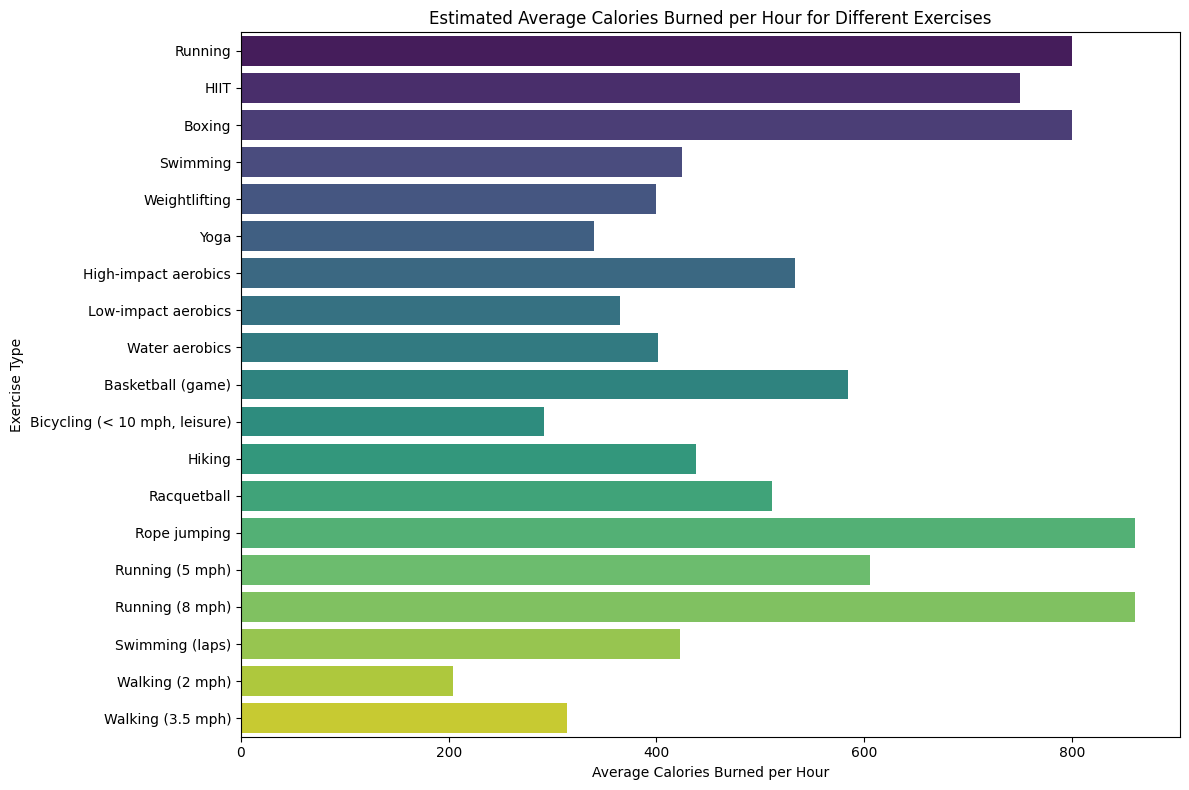

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data (estimated average calories burned per hour)
data = {
    'Exercise': ['Running', 'HIIT', 'Boxing', 'Swimming', 'Weightlifting', 'Yoga',
                 'High-impact aerobics', 'Low-impact aerobics', 'Water aerobics',
                 'Basketball (game)', 'Bicycling (< 10 mph, leisure)', 'Hiking',
                 'Racquetball', 'Rope jumping', 'Running (5 mph)', 'Running (8 mph)',
                 'Swimming (laps)', 'Walking (2 mph)', 'Walking (3.5 mph)'],
    'Calories Burned': [800, 750, 800, 425, 400, 340, 533, 365, 402, 584, 292, 438,
                        511, 861, 606, 861, 423, 204, 314]
}

df = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability
sns.barplot(x='Calories Burned', y='Exercise', data=df, palette='viridis')
plt.xlabel('Average Calories Burned per Hour')
plt.ylabel('Exercise Type')
plt.title('Estimated Average Calories Burned per Hour for Different Exercises')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping

# To display the chart, you need to run this in an environment that supports graphical output
plt.show()